# 04 — Stage 2 CTX Retrieval QA: ESP_069669_2220

Visual sanity check for the windowed CTX read produced by `src.ctx_retrieve.stage2_one_image`. The Stage 1 detections (cached at `cache/reprojected_detections/{ObsId}.gpkg`) are overlaid on the cached CTX window (`cache/ctx_windows/{ObsId}.tif`).

If Stages 1 and 2 agree, boulder polygons should land on the dotted / textured features in the CTX intensity. The CTX mosaic is 5 m/pixel and one boulder is typically smaller than that, so individual boulders rarely show as distinct dots — but boulder fields show up as elevated texture / shadow noise.

Imports from `src/`; the notebook is for inspection only.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from src import detections, manifest as M
from src.config import load_config, REPO_ROOT
from src.ctx_retrieve import CTX_TILES_SUBDIR, CTX_WINDOWS_SUBDIR

# Dataset selector: defaults to the vClaire 40-image v2 dataset; set "config.yaml" for v1.
CONFIG_NAME = "config_v2.yaml"
OBS_ID = "ESP_069669_2220"   # in both v1+v2; under v2 the window has the denser vClaire detections
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(CONFIG_NAME)
df = M.load_manifest(cfg.manifest_path)
row = df.set_index("ObsId").loc[OBS_ID]
print(f"config: {CONFIG_NAME}   detections_root: {cfg.detections_root.name}")
print(f"ObsId: {OBS_ID}  CTX_TileName: {row['CTX_TileName']}  BoulderLabel: {row['BoulderLabel']}")

config: config_v2.yaml   detections_root: hirise_40_vClaire
ObsId: ESP_069669_2220  CTX_TileName: E000_N40  BoulderLabel: Boulder rich


In [2]:
window_tif = cfg.cache_dir / CTX_WINDOWS_SUBDIR / f"{OBS_ID}.tif"
window_sidecar = cfg.cache_dir / CTX_WINDOWS_SUBDIR / f"{OBS_ID}.json"
assert window_tif.exists(), f"missing {window_tif} — run scripts/run_stage2.py {OBS_ID} first"

with rasterio.open(window_tif) as src:
    ctx = src.read(1)
    ctx_bounds = src.bounds
    ctx_transform = src.transform
    ctx_crs = src.crs
    ctx_crs_name = src.crs.to_dict().get("proj", str(src.crs)) if src.crs else "<none>"

prov = json.loads(window_sidecar.read_text(encoding="utf-8"))
print(f"window shape: {ctx.shape}  dtype: {ctx.dtype}")
print(f"window bounds: x [{ctx_bounds.left:.1f}, {ctx_bounds.right:.1f}] m, y [{ctx_bounds.bottom:.1f}, {ctx_bounds.top:.1f}] m")
print(f"window size: {(ctx_bounds.right - ctx_bounds.left) / 1000:.2f} km E-W x {(ctx_bounds.top - ctx_bounds.bottom) / 1000:.2f} km N-S")
print(f"source tile: {prov['source_murray_tile']}  ({prov['source_inner_tif']})")
print(f"buffer: {prov['buffer_m']} m   footprint_source: {prov['footprint_source']}   n_polygons: {prov['n_polygons_anchor']}")

window shape: (3566, 2335)  dtype: uint8
window bounds: x [38414.8, 50089.7] m, y [2469682.4, 2487512.3] m
window size: 11.67 km E-W x 17.83 km N-S
source tile: E0_N40  (MurrayLab_GlobalCTXMosaic_V01_E000_N40/MurrayLab_CTX_V01_E000_N40_Mosaic.tif)
buffer: 1000.0 m   footprint_source: polygon_bbox   n_polygons: 35238


In [3]:
# Intensity sanity: real CTX data should have non-trivial spread; an all-zero window would
# mean we read off the tile edge or hit a no-data region.
valid = ctx[ctx > 0] if np.any(ctx > 0) else ctx.ravel()
print(f"intensity: min {ctx.min()}  max {ctx.max()}  mean {ctx.mean():.1f}  std {ctx.std():.1f}")
print(f"non-zero pixels: {(ctx > 0).sum() / ctx.size:.1%} of window")
if valid.size > 0:
    print(f"non-zero stats: mean {valid.mean():.1f}  std {valid.std():.1f}  min {valid.min()}  max {valid.max()}")

intensity: min 1  max 238  mean 93.3  std 30.9
non-zero pixels: 100.0% of window
non-zero stats: mean 93.3  std 30.9  min 1  max 238


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\04_ctx_window_ESP_069669_2220.png


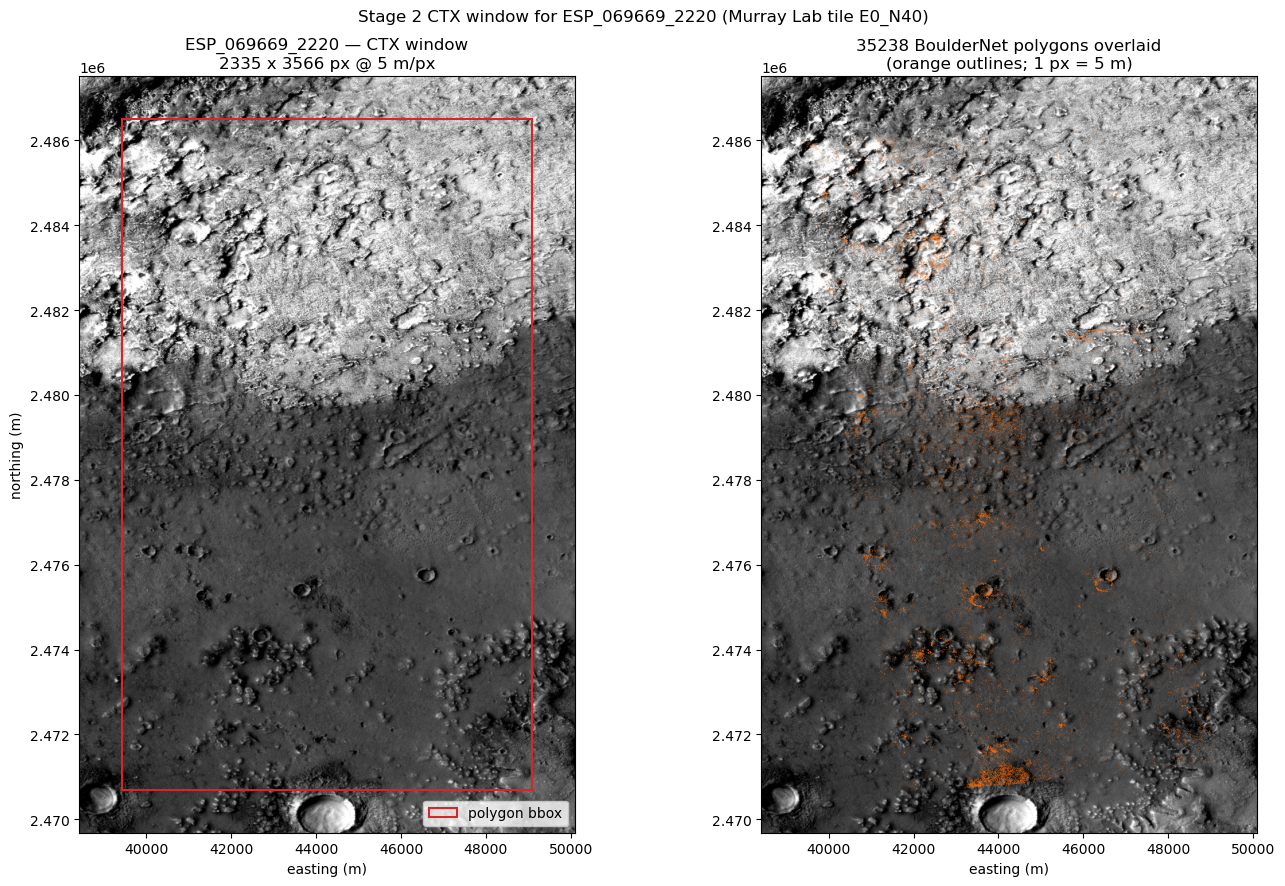

In [4]:
gdf = detections.load_reprojected(OBS_ID, cfg.cache_dir)
poly_bounds = gdf.total_bounds

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

extent = (ctx_bounds.left, ctx_bounds.right, ctx_bounds.bottom, ctx_bounds.top)
vmin, vmax = np.percentile(ctx[ctx > 0], [2, 98]) if (ctx > 0).any() else (0, 1)

# Left: CTX only, with polygon-bbox outline
axes[0].imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
axes[0].add_patch(
    plt.Rectangle(
        (poly_bounds[0], poly_bounds[1]),
        poly_bounds[2] - poly_bounds[0],
        poly_bounds[3] - poly_bounds[1],
        fill=False, edgecolor="#d62728", linewidth=1.5, label="polygon bbox",
    )
)
axes[0].set_xlabel("easting (m)"); axes[0].set_ylabel("northing (m)")
axes[0].set_title(f"{OBS_ID} — CTX window\n{ctx.shape[1]} x {ctx.shape[0]} px @ 5 m/px")
axes[0].set_aspect("equal"); axes[0].legend(loc="lower right")

# Right: CTX with polygons overlaid
axes[1].imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
gdf.plot(ax=axes[1], facecolor="none", edgecolor="#ff6f0e", linewidth=0.35, alpha=0.9)
axes[1].set_xlim(extent[0], extent[1]); axes[1].set_ylim(extent[2], extent[3])
axes[1].set_xlabel("easting (m)")
axes[1].set_title(f"{len(gdf)} BoulderNet polygons overlaid\n(orange outlines; 1 px = 5 m)")
axes[1].set_aspect("equal")

fig.suptitle(f"Stage 2 CTX window for {OBS_ID} (Murray Lab tile {prov['source_murray_tile']})")
fig.tight_layout()
out_path = FIG_DIR / f"04_ctx_window_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")

In [5]:
# Cheap inside-vs-outside-polygon-bbox intensity check. A real boulder-rich CTX window
# should have slightly LOWER mean / slightly HIGHER std inside the polygon bbox than
# outside it (boulders cast shadows -> texture). This is just a smoke test, not a real
# feature — Stage 4 will compute proper GLCM features.
from rasterio.windows import from_bounds as rio_from_bounds
with rasterio.open(window_tif) as src:
    inner_win = rio_from_bounds(*poly_bounds, transform=src.transform).round_offsets()
    inner = src.read(1, window=inner_win)
    full = src.read(1)

# Outside = full minus inner. Approximate by masking — full has shape (H, W); inner is contiguous.
mask = np.ones_like(full, dtype=bool)
ro = int(inner_win.row_off); co = int(inner_win.col_off)
rh = int(inner_win.height); rw = int(inner_win.width)
ro_c = max(0, ro); co_c = max(0, co)
re_c = min(full.shape[0], ro + rh); ce_c = min(full.shape[1], co + rw)
if re_c > ro_c and ce_c > co_c:
    mask[ro_c:re_c, co_c:ce_c] = False
outside = full[mask & (full > 0)]
inner_valid = inner[inner > 0]
if inner_valid.size and outside.size:
    print(f"inside-bbox  mean {inner_valid.mean():6.1f}  std {inner_valid.std():5.1f}  n={inner_valid.size}")
    print(f"outside-bbox mean {outside.mean():6.1f}  std {outside.std():5.1f}  n={outside.size}")
else:
    print("insufficient data for inside/outside split (probably a tile-edge case)")

inside-bbox  mean   93.8  std  30.6  n=6119878
outside-bbox mean   92.0  std  31.9  n=2208665


## HiRISE-on-CTX comparison

The CTX window is a fattened bbox; the HiRISE footprint is a thin diagonal swath inside it. Reprojecting the cached decimated HiRISE (`cache/hirise_decimated/{ObsId}_5mpp_full.tif`, in its SP1-corrected source CRS) onto the CTX window's grid shows exactly which CTX pixels actually have a HiRISE counterpart — useful for spotting how much of the bbox is wasted area outside the actual HiRISE swath.

Left panel: HiRISE warped onto the CTX window grid (any CTX pixel outside the HiRISE swath is masked).  
Right panel: the same CTX window with just the polygon-footprint bbox outlined (no polygon overlay — easier to compare the swath shape to the bbox approximation).

HiRISE decimated: shape (3170, 1486)  dtype uint16  CRS eqc


HiRISE coverage of CTX window: 56.5%


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\04_hirise_vs_ctx_ESP_069669_2220.png


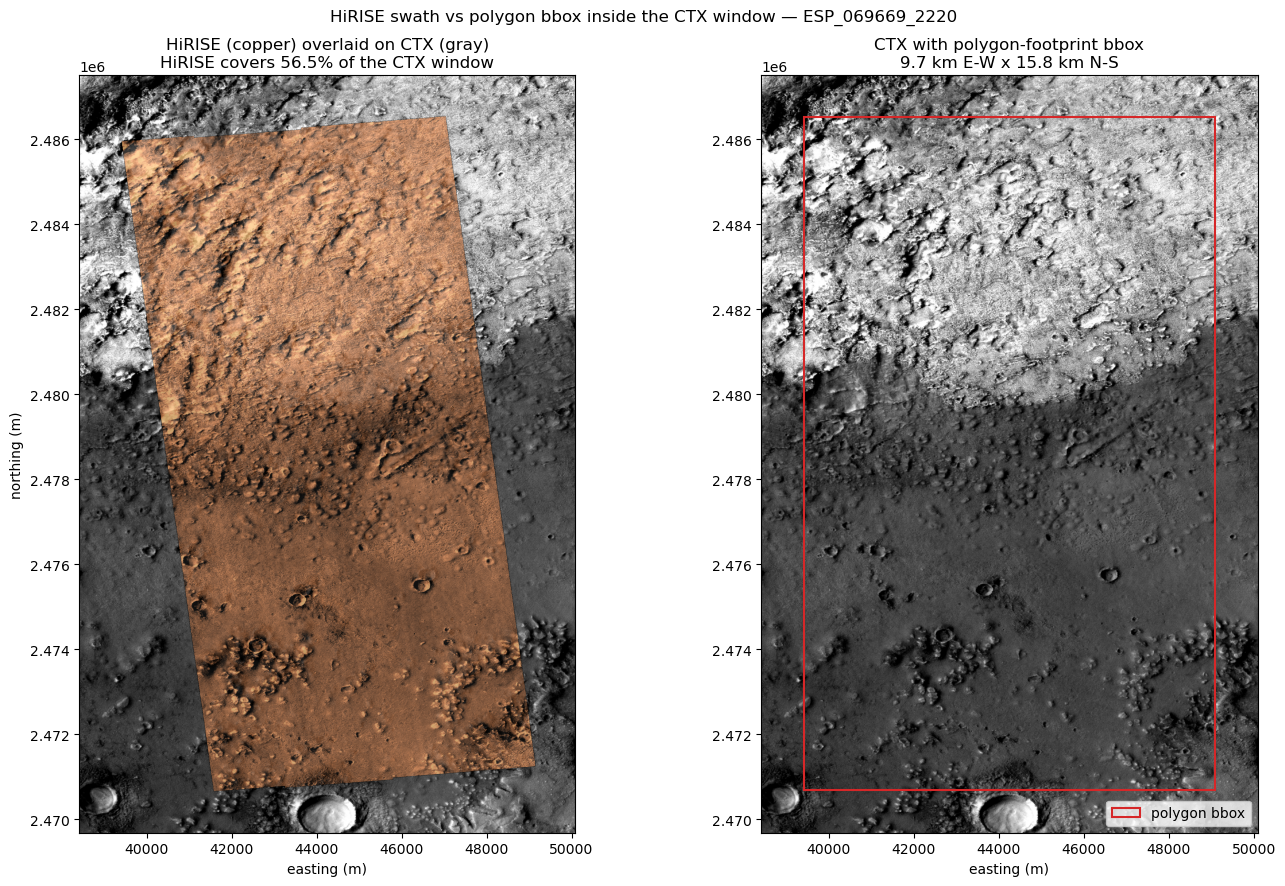

In [6]:
from rasterio.enums import Resampling
from rasterio.warp import reproject

from src import hirise_imagery

# Load decimated HiRISE (already cached from prior notebooks; 5 m/px ~matches CTX).
hi_arr, hi_transform, hi_crs = hirise_imagery.read_full_footprint_decimated(
    OBS_ID, row["JP2_URL"], cfg.cache_dir, target_mpp=5.0,
)
print(f"HiRISE decimated: shape {hi_arr.shape}  dtype {hi_arr.dtype}  CRS {hi_crs.to_dict().get('proj', hi_crs)}")

# Warp HiRISE onto the CTX window's exact grid so the two arrays are pixel-comparable.
hi_on_ctx = np.zeros_like(ctx, dtype=np.float32)
reproject(
    source=hi_arr,
    destination=hi_on_ctx,
    src_transform=hi_transform,
    src_crs=hi_crs,
    dst_transform=ctx_transform,
    dst_crs=ctx_crs,
    src_nodata=0,
    dst_nodata=0,
    resampling=Resampling.bilinear,
)
hi_coverage = (hi_on_ctx > 0).mean()
print(f"HiRISE coverage of CTX window: {hi_coverage:.1%}")

# Stretch HiRISE to its own valid range (HiRISE is uint16, mostly low values)
valid_hi = hi_on_ctx[hi_on_ctx > 0]
hi_vmin, hi_vmax = np.percentile(valid_hi, [2, 98]) if valid_hi.size else (0, 1)
hi_masked = np.ma.masked_where(hi_on_ctx == 0, hi_on_ctx)

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# Left: CTX as base, HiRISE swath overlaid in cool-colored alpha
axes[0].imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
axes[0].imshow(hi_masked, cmap="copper", extent=extent, vmin=hi_vmin, vmax=hi_vmax, origin="upper", alpha=0.75)
axes[0].set_xlabel("easting (m)"); axes[0].set_ylabel("northing (m)")
axes[0].set_title(f"HiRISE (copper) overlaid on CTX (gray)\nHiRISE covers {hi_coverage:.1%} of the CTX window")
axes[0].set_aspect("equal")

# Right: CTX with polygon-bbox outline only (no polygons drawn)
axes[1].imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
axes[1].add_patch(
    plt.Rectangle(
        (poly_bounds[0], poly_bounds[1]),
        poly_bounds[2] - poly_bounds[0],
        poly_bounds[3] - poly_bounds[1],
        fill=False, edgecolor="#d62728", linewidth=1.5, label="polygon bbox",
    )
)
axes[1].set_xlabel("easting (m)")
axes[1].set_title(f"CTX with polygon-footprint bbox\n{(poly_bounds[2]-poly_bounds[0])/1000:.1f} km E-W x {(poly_bounds[3]-poly_bounds[1])/1000:.1f} km N-S")
axes[1].set_aspect("equal"); axes[1].legend(loc="lower right")

fig.suptitle(f"HiRISE swath vs polygon bbox inside the CTX window — {OBS_ID}")
fig.tight_layout()
out_path = FIG_DIR / f"04_hirise_vs_ctx_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")

## HiRISE coverage mask (gates Stage 4 labels)

Stage 2 also writes `cache/ctx_windows/{ObsId}_hirise_mask.tif`: uint8, 1 where decimated HiRISE has a valid pixel after reprojection onto the CTX grid, 0 elsewhere. Stage 4 must drop tiles where the mask isn't fully 1 — otherwise the polygon-bbox window's ~40% of HiRISE-unobserved area would be miscounted as 'no-boulder' tiles (the absence is 'unobserved', not 'absent'). See DECISIONS.md 2026-05-21 'Labels-only-on-HiRISE-coverage constraint'.

mask shape: (3566, 2335)  coverage: 56.5%


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\04_hirise_mask_ESP_069669_2220.png


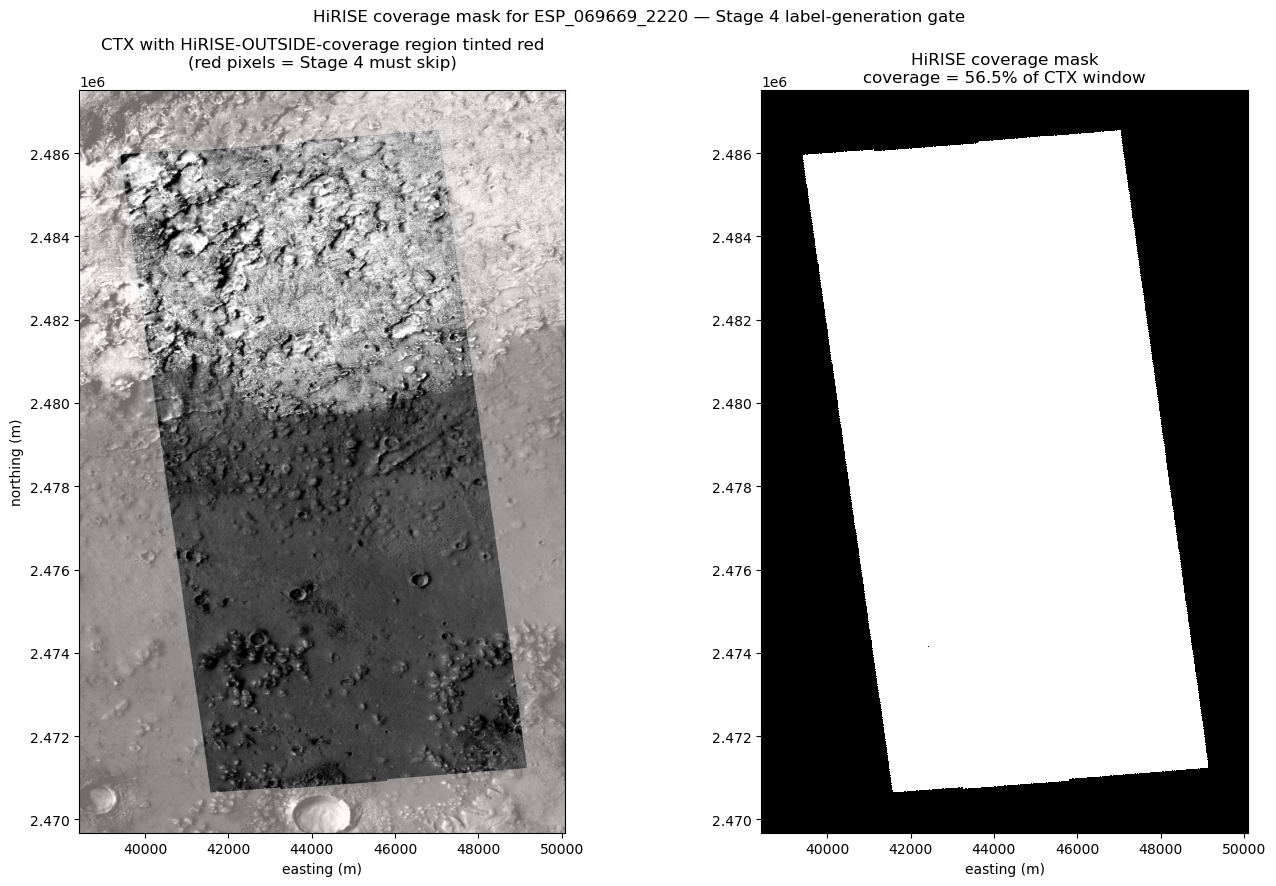

In [7]:
mask_tif = cfg.cache_dir / CTX_WINDOWS_SUBDIR / f"{OBS_ID}_hirise_mask.tif"
assert mask_tif.exists(), f"missing {mask_tif} — re-run scripts/run_stage2.py {OBS_ID}"
with rasterio.open(mask_tif) as src:
    mask = src.read(1)
assert mask.shape == ctx.shape, f"mask shape {mask.shape} != CTX shape {ctx.shape}"
coverage = float(mask.mean())
print(f"mask shape: {mask.shape}  coverage: {coverage:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
# Left: CTX with OUTSIDE-mask pixels tinted red so the gated region is obvious
axes[0].imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
axes[0].imshow(
    np.ma.masked_where(mask == 1, mask),
    cmap="Reds", alpha=0.45, extent=extent, origin="upper",
)
axes[0].set_xlabel("easting (m)"); axes[0].set_ylabel("northing (m)")
axes[0].set_title("CTX with HiRISE-OUTSIDE-coverage region tinted red\n(red pixels = Stage 4 must skip)")
axes[0].set_aspect("equal")

# Right: the mask itself
axes[1].imshow(mask, cmap="gray", extent=extent, origin="upper", interpolation="nearest")
axes[1].set_xlabel("easting (m)")
axes[1].set_title(f"HiRISE coverage mask\ncoverage = {coverage:.1%} of CTX window")
axes[1].set_aspect("equal")

fig.suptitle(f"HiRISE coverage mask for {OBS_ID} — Stage 4 label-generation gate")
fig.tight_layout()
out_path = FIG_DIR / f"04_hirise_mask_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")

## Zoomed views (coarse + fine)

Two scales of zoom into the densest part of the polygon distribution. The 1.5 km × 1.5 km cell shows clustering at a neighborhood scale (and how the polygons concentrate in one corner of the cell). The 500 m × 500 m cell zooms further so individual polygon outlines are clearly resolvable against the CTX texture (1 polygon ≈ 1 CTX pixel, but the polygon outline draws above the pixel).

densest 1.5 km cell: x [42915, 44415] m, y [2478682, 2480182] m
polygons in zoom cell: 2890
polygons intersecting zoom box (after clip): 2895


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\04_ctx_zoom_ESP_069669_2220.png


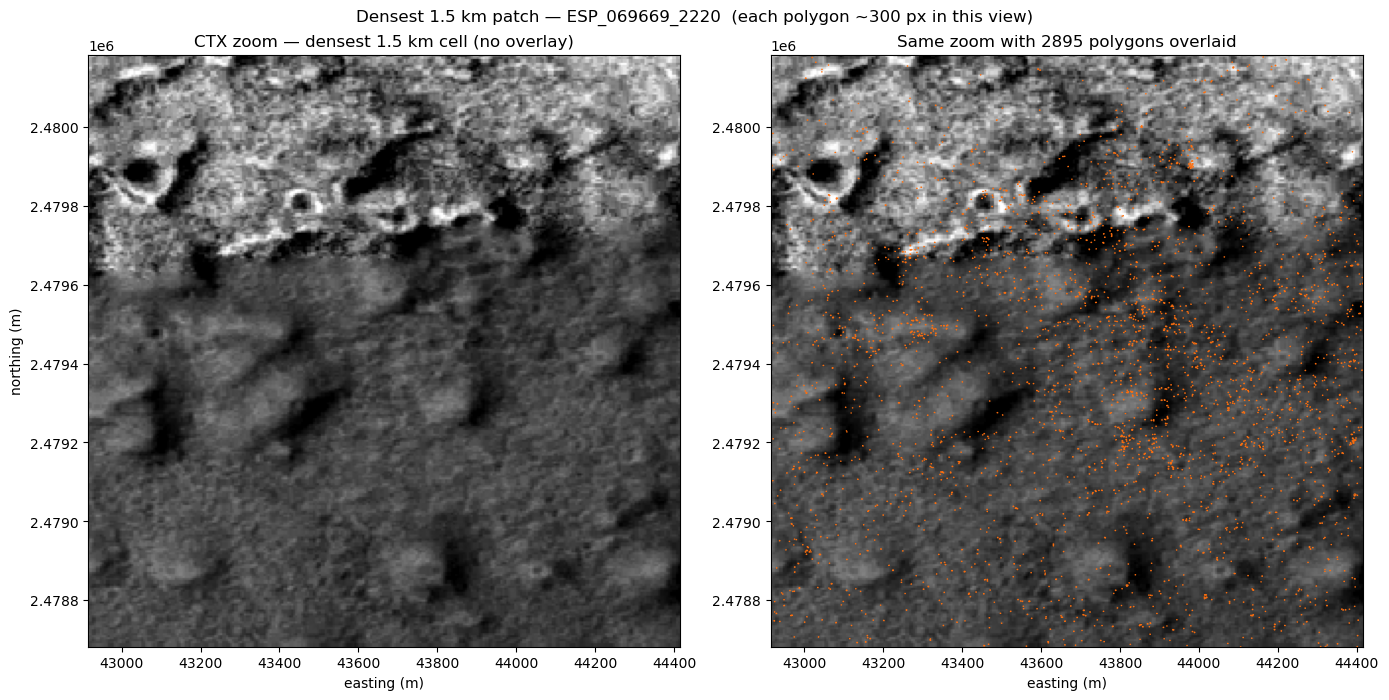

In [8]:
# Find the densest 1.5km square patch by binning polygon centroids on a coarse grid.
CELL_KM = 1.5
cell_m = CELL_KM * 1000.0
centroids = np.column_stack([gdf.geometry.centroid.x.to_numpy(), gdf.geometry.centroid.y.to_numpy()])
x_edges = np.arange(ctx_bounds.left, ctx_bounds.right + cell_m, cell_m)
y_edges = np.arange(ctx_bounds.bottom, ctx_bounds.top + cell_m, cell_m)
H, _, _ = np.histogram2d(centroids[:, 0], centroids[:, 1], bins=[x_edges, y_edges])
ix, iy = np.unravel_index(np.argmax(H), H.shape)
zoom_xmin, zoom_xmax = x_edges[ix], x_edges[ix + 1]
zoom_ymin, zoom_ymax = y_edges[iy], y_edges[iy + 1]
n_polys_in_zoom = int(H[ix, iy])
print(f"densest {CELL_KM} km cell: x [{zoom_xmin:.0f}, {zoom_xmax:.0f}] m, y [{zoom_ymin:.0f}, {zoom_ymax:.0f}] m")
print(f"polygons in zoom cell: {n_polys_in_zoom}")

# Clip GeoDataFrame to the zoom box for plotting (faster than plotting all 1462)
from shapely.geometry import box
zoom_box = box(zoom_xmin, zoom_ymin, zoom_xmax, zoom_ymax)
gdf_zoom = gdf[gdf.geometry.intersects(zoom_box)]
print(f"polygons intersecting zoom box (after clip): {len(gdf_zoom)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax in axes:
    ax.imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xlim(zoom_xmin, zoom_xmax)
    ax.set_ylim(zoom_ymin, zoom_ymax)
    ax.set_aspect("equal")
    ax.set_xlabel("easting (m)")

axes[0].set_ylabel("northing (m)")
axes[0].set_title(f"CTX zoom — densest {CELL_KM} km cell (no overlay)")

gdf_zoom.plot(ax=axes[1], facecolor="none", edgecolor="#ff6f0e", linewidth=0.7, alpha=0.95)
axes[1].set_title(f"Same zoom with {len(gdf_zoom)} polygons overlaid")

fig.suptitle(f"Densest {CELL_KM} km patch — {OBS_ID}  (each polygon ~300 px in this view)")
fig.tight_layout()
out_path = FIG_DIR / f"04_ctx_zoom_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")

densest 0.5 km cell: x [43415, 43915] m, y [2470682, 2471182] m
polygons in fine zoom cell: 1118


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\04_ctx_zoom_fine_ESP_069669_2220.png


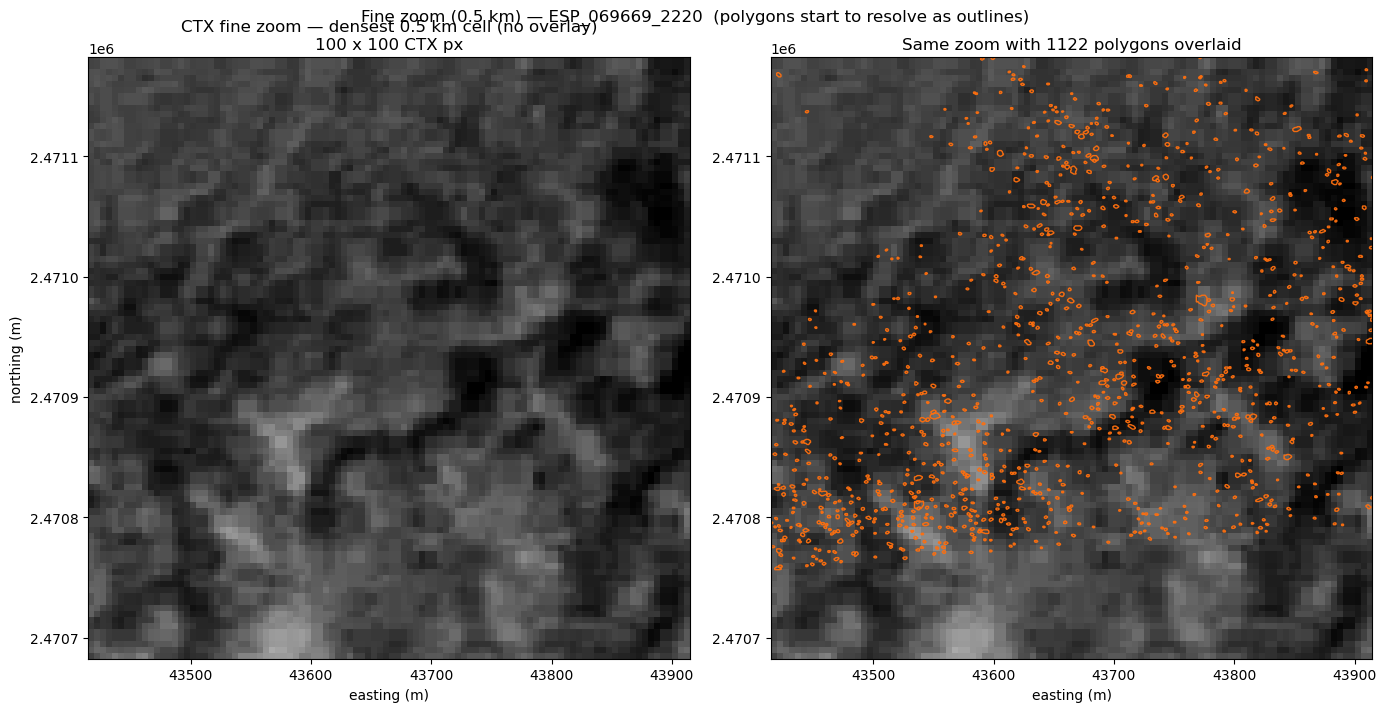

In [9]:
from shapely.geometry import box as _shp_box

# Second zoom: 500 m densest cell. Independent search (not constrained to the 1.5 km cell)
# so the two scales each pick their own optimum; they often coincide for boulder-rich images.
CELL_KM_FINE = 0.5
cell_m_fine = CELL_KM_FINE * 1000.0
x_edges_f = np.arange(ctx_bounds.left, ctx_bounds.right + cell_m_fine, cell_m_fine)
y_edges_f = np.arange(ctx_bounds.bottom, ctx_bounds.top + cell_m_fine, cell_m_fine)
H_f, _, _ = np.histogram2d(centroids[:, 0], centroids[:, 1], bins=[x_edges_f, y_edges_f])
ix_f, iy_f = np.unravel_index(np.argmax(H_f), H_f.shape)
fz_xmin, fz_xmax = x_edges_f[ix_f], x_edges_f[ix_f + 1]
fz_ymin, fz_ymax = y_edges_f[iy_f], y_edges_f[iy_f + 1]
n_polys_fine = int(H_f[ix_f, iy_f])
print(f"densest {CELL_KM_FINE} km cell: x [{fz_xmin:.0f}, {fz_xmax:.0f}] m, y [{fz_ymin:.0f}, {fz_ymax:.0f}] m")
print(f"polygons in fine zoom cell: {n_polys_fine}")

fz_box = _shp_box(fz_xmin, fz_ymin, fz_xmax, fz_ymax)
gdf_fine = gdf[gdf.geometry.intersects(fz_box)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax in axes:
    ax.imshow(ctx, cmap="gray", extent=extent, vmin=vmin, vmax=vmax, origin="upper",
              interpolation="nearest")
    ax.set_xlim(fz_xmin, fz_xmax)
    ax.set_ylim(fz_ymin, fz_ymax)
    ax.set_aspect("equal")
    ax.set_xlabel("easting (m)")
axes[0].set_ylabel("northing (m)")
axes[0].set_title(f"CTX fine zoom — densest {CELL_KM_FINE} km cell (no overlay)\n100 x 100 CTX px")

gdf_fine.plot(ax=axes[1], facecolor="none", edgecolor="#ff6f0e", linewidth=1.0, alpha=0.95)
axes[1].set_title(f"Same zoom with {len(gdf_fine)} polygons overlaid")

fig.suptitle(f"Fine zoom ({CELL_KM_FINE} km) — {OBS_ID}  (polygons start to resolve as outlines)")
fig.tight_layout()
out_path = FIG_DIR / f"04_ctx_zoom_fine_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")